In [7]:
import pandas as pd

# Import CSV data into Pandas dataframe

# 'datadirectory' = folder path string
datadirectory = '/Users/jcoleman/Documents/--LARGE DATA--/#Febo/thy1gcamp6s data set/'
# 'datafile' = full CSV filename string
datafile = 'mThy6s2_alldrift_D4_001Z1_ROIdata.csv'

df = pd.read_csv(datadirectory + datafile)

print("datafile size (row, column) = " + str(df.shape))
print("  No. of frames = " + str(df.shape[0]))
print("  No. of frames = " + str(df.shape[1]))

datafile size (row, column) = (16200, 321)
No. of frames = 16200


In [16]:
#Get specific headers (choose from:
calcium_data_headers = ['Area',
                        'Mean', 
                        'X',
                        'Y',
                        'Circ',
                        'IntDen',
                        'RawIntDen',
                        'AR',
                        'Round',
                        'Solidity']
calcium_data_headers

['Area',
 'Mean',
 'X',
 'Y',
 'Circ',
 'IntDen',
 'RawIntDen',
 'AR',
 'Round',
 'Solidity']

In [38]:
#raw signal data 
# use 'RawIntDen' columns, ie the raw integrated density values or pixel brightness
#  *note IntDen columns are the same, but use the RawIntDen columns for this code per convention
# gray values between 0-64000 where 0=black, 64000=white
print(df.filter(like=calcium_data_headers[6]).columns)

Index(['RawIntDen1', 'RawIntDen2', 'RawIntDen3', 'RawIntDen4', 'RawIntDen5',
       'RawIntDen6', 'RawIntDen7', 'RawIntDen8', 'RawIntDen9', 'RawIntDen10',
       'RawIntDen11', 'RawIntDen12', 'RawIntDen13', 'RawIntDen14',
       'RawIntDen15', 'RawIntDen16', 'RawIntDen17', 'RawIntDen18',
       'RawIntDen19', 'RawIntDen20', 'RawIntDen21', 'RawIntDen22',
       'RawIntDen23', 'RawIntDen24', 'RawIntDen25', 'RawIntDen26',
       'RawIntDen27', 'RawIntDen28', 'RawIntDen29', 'RawIntDen30',
       'RawIntDen31', 'RawIntDen32'],
      dtype='object')


In [39]:
df2 = df.filter(regex=calcium_data_headers[6])
print(df2)

       RawIntDen1  RawIntDen2  RawIntDen3  RawIntDen4  RawIntDen5  RawIntDen6  \
0           17602       20989       26255       32601       40946       33187   
1           18156       28640       34145       32478       47460       27562   
2           20166       27714       40971       26238       60221       33650   
3           16640       22489       33702       29435       47673       33869   
4           17893       39759       26319       33763       41442       38588   
...           ...         ...         ...         ...         ...         ...   
16195       17941       24319       39002       39927       50059       39550   
16196       30227       25229       26793       54767       44798       40577   
16197       27882       30178       30333       41295       49095       44854   
16198       29619       30662       29865       34942       48728       37818   
16199       22252       49975       33839       43619       41864       44824   

       RawIntDen7  RawIntDe

In [56]:
import numpy as np

df2_array = df2.to_numpy()
#df[["column1","column2"]].to_numpy()

#df2_array_reshape = df2_array.reshape(32,16200)

#df2_array_reshape.shape

(32, 16200)

In [84]:
(df2_array[:,31])

array([18588, 17351, 22779, ..., 14075, 21267, 14990])

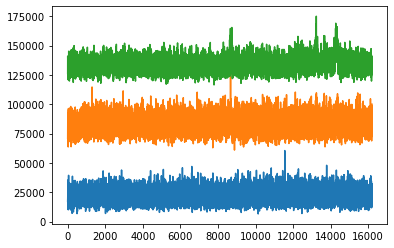

In [100]:
from matplotlib import pyplot as plt

#each row in df2_array is signal from a single region of interest (ROI = single GCaMP6s+ cell)
#plot the first 3 ROI traces (with incremental increase in amplitude for plotting only)
plt.plot(df2_array[:,0])
plt.plot(df2_array[:,1]+50000)
plt.plot(df2_array[:,2]+100000)

In [ ]:
# Timestamps
# frames_Hz = 30

# Plot vertical lines
#   (60s delay before forst stim onset | 5sec stim/visual | 7sec gray/rest | repeat for 7 more stims/grays) 
#   (Total 8 drifting grating stims = 0,45,90,135,180,225,270,315 degrees (off horizon))
# 1) start_delay [0]
# 2) stop_delay (60s delay before forst stim onset) [60*frames_Hz]
# 3) start_stim1 [stop_delay + 1]
# 4) stop_stim1 [stop_delay + 5*frames_Hz]
# 5) start_gray1 [stop_stim1 + 1]
# 6) stop_gray1 [stop_stim1 + 7*frames_Hz]
# 7) start_stim2 [stop_gray1 + 1]
# 8) stop_stim2 [stop_gray1 + 5*frames_Hz]
# 9) start_gray2 [stop_stim2 + 1]
#10) stop_gray2 [stop_stim2 = 7*frames_Hz]
#11) start_stim3 [stop_gray1 + 1] ...
# ... repeat up until stim8 / gray8
